In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle, Patch

### Figure S1. Theoretical relationship between harem size (NeF/NeM) and X/AUT diversity with different ɑ values

In [425]:
def calculate_thetas(harem_size, alpha):
    Ne_m = 1
    Ne_f = harem_size * Ne_m

    Ne_AUT = (4 * Ne_f * Ne_m) / (Ne_f + Ne_m)
    Ne_X = (9 * Ne_f * Ne_m) / (2 * Ne_f + 4 * Ne_m)

    mu_X = ((2+alpha)/3)
    mu_AUT = ((1+alpha)/2)

    theta_X = 4 * mu_X * Ne_X
    theta_AUT = 4 * mu_AUT * Ne_AUT

    return theta_X, theta_AUT

In [52]:
print(sns.color_palette("plasma", 5).as_hex())
sns.color_palette("plasma", 5).as_hex()

['#5c01a6', '#9c179e', '#cc4778', '#ed7953', '#fdb42f']


['#5c01a6', '#9c179e', '#cc4778', '#ed7953', '#fdb42f']

/dss/lxclscratch/08/ra63rof/ra63rof/ipykernel_106490/1120045755.py:13: RuntimeWarning: invalid value encountered in scalar divide
  theta_vals.append(theta_X/theta_AUT)


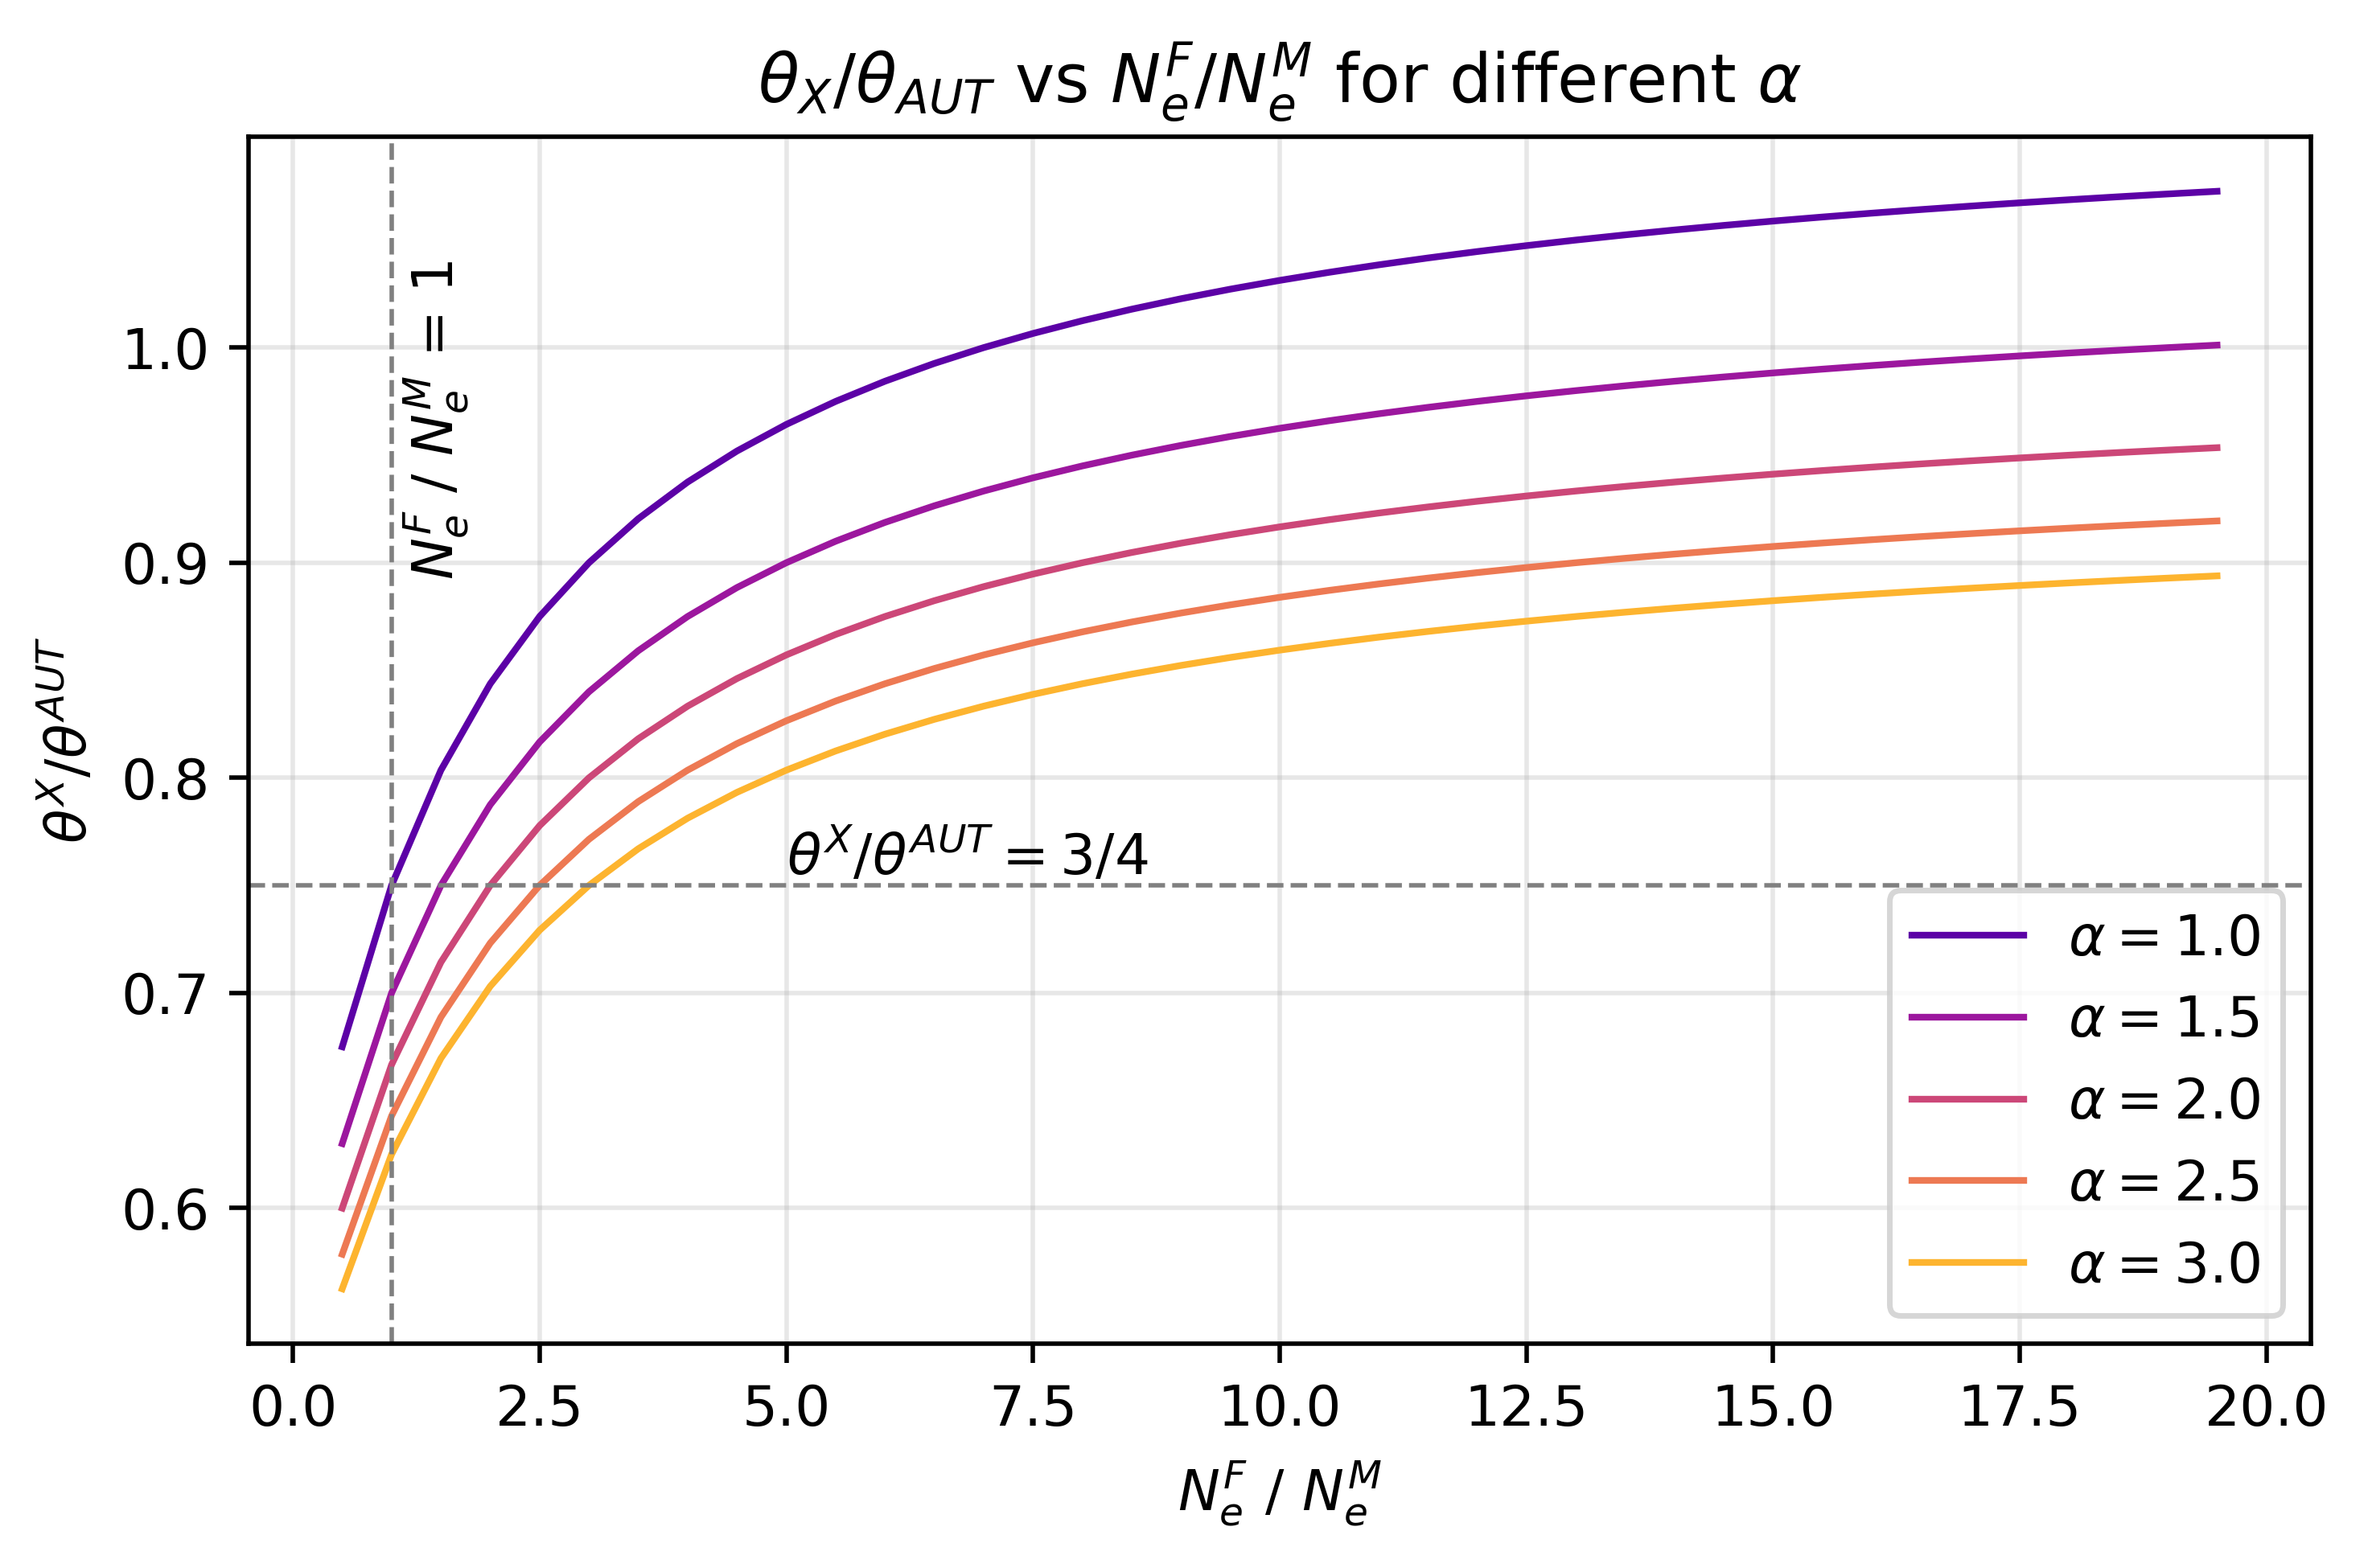

In [426]:
alphas = np.arange(1, 3.1, 0.5)
harem_sizes = np.arange(0, 20, 0.5)
# mu_ratios = [0.7, 0.85, 1.0]

colors = sns.color_palette("plasma", len(alphas)).as_hex()
plt.figure(figsize=(6, 4), dpi=500)

for i_alpha, alpha in enumerate(alphas):
    theta_vals = []

    for harem_size in harem_sizes:
        theta_X, theta_AUT = calculate_thetas(harem_size, alpha)
        theta_vals.append(theta_X/theta_AUT)

    plt.plot(harem_sizes, theta_vals, 
                label=rf"$\alpha={alpha}$",
                linestyle="-",
                color=colors[i_alpha], 
                linewidth=1.2
            )
plt.axvline(x=1, color='gray', linestyle='--', linewidth=0.8)
plt.text(1.1,0.9,r"$N_e^F$ / $N_e^M$ = 1",rotation=90)
plt.axhline(y=0.75, color='gray', linestyle='--', linewidth=0.8)
plt.text(5.0,0.755,r"$\theta^X / \theta^{AUT} = 3/4$",rotation=0)

plt.xlabel(r"$N_e^F$ / $N_e^M$")
plt.ylabel(r"$\theta^X / \theta^{AUT}$")
plt.title(r"$\theta_X/\theta_{AUT}$ vs $N_e^F/N_e^M$ for different $\alpha$")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Supplementary Text 2.5. Effect of filtering on Watterson’s theta (θW) and genetic diversity (π)estimations

In [123]:
def combine_stats(coords_pixy, coords_ANGSD, alpha=3, ylabel="", title=""):
    harem_sizes = np.arange(0.00001, 10, 0.5)

    colors = sns.color_palette("plasma", 5).as_hex()
    fig, ax = plt.subplots(figsize=(6, 3))

    theta_vals = []

    for harem_size in harem_sizes:
        theta_X, theta_AUT = calculate_thetas(harem_size, alpha)
        theta_vals.append(theta_X/theta_AUT)

    plt.plot(harem_sizes, theta_vals,
                linestyle="-",
                color=colors[4], 
                linewidth=1.2
            )

    for (harem,stats) in coords_pixy:
        plt.axvline(x=harem, color='#ed7953', linestyle='--', linewidth=0.8)
        plt.axhline(y=stats, color='#ed7953', linestyle='--', linewidth=0.8)
    rect = Rectangle((min(coords_pixy[:,0]), min(coords_pixy[:,1])), 
                    max(coords_pixy[:,0]) - min(coords_pixy[:,0]), 
                    max(coords_pixy[:,1]) - min(coords_pixy[:,1]), 
                    facecolor="#ed7953", edgecolor="none", alpha=0.5)
    ax.add_patch(rect)

    for (harem,stats) in coords_ANGSD:
        plt.axvline(x=harem, color='#9c179e', linestyle='--', linewidth=0.8)
        plt.axhline(y=stats, color='#9c179e', linestyle='--', linewidth=0.8)
    rect = Rectangle((min(coords_ANGSD[:,0]), min(coords_ANGSD[:,1])), 
                    max(coords_ANGSD[:,0]) - min(coords_ANGSD[:,0]), 
                    max(coords_ANGSD[:,1]) - min(coords_ANGSD[:,1]), 
                    facecolor="#9c179e", edgecolor="none", alpha=0.5)
    ax.add_patch(rect)

    legend_elements = [
        Patch(facecolor="#ed7953", label="pixy"),
        Patch(facecolor="#9c179e", label="ANGSD")
    ]

    ax.legend(
        handles=legend_elements,
        title="Tools",
        loc="lower right",
        frameon=True
    )
    plt.xlabel(r"$N_e^F$ / $N_e^M$ (harem size)")
    plt.ylabel(ylabel)
    plt.title(title)

    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

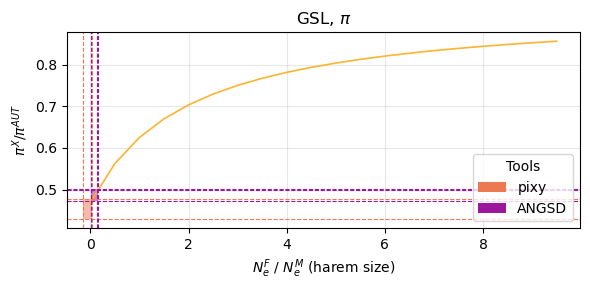

In [124]:
combine_stats(coords_pixy = np.array([(-0.15691, 0.42884), (0.03463, 0.47673)]), 
              coords_ANGSD = np.array([(0.01799, 0.47293), (0.15479, 0.50242), (0.13865, 0.49914)]), 
              alpha=3, 
              ylabel=r"$\pi^X / \pi^{AUT}$",
              title=r"GSL, $\pi$")

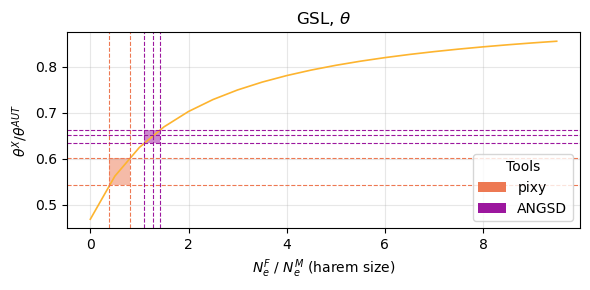

In [125]:
combine_stats(coords_pixy = np.array([(0.80127, 0.60283), (0.38335, 0.54415)]), 
              coords_ANGSD = np.array([(1.08542, 0.63365), (1.41134, 0.66268), (1.28466, 0.65208)]), 
              alpha=3, 
              ylabel=r"$\theta^X / \theta^{AUT}$",
              title=r"GSL, $\theta$")

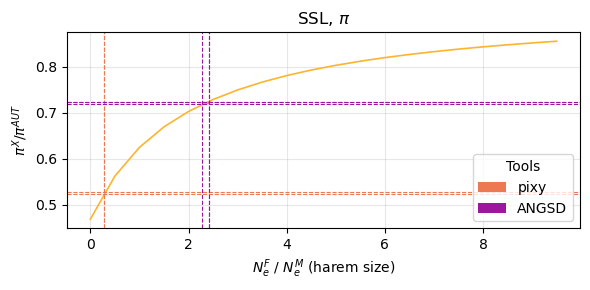

In [126]:
combine_stats(coords_pixy = np.array([(0.28357, 0.52696), (0.27071, 0.52463)]), 
              coords_ANGSD = np.array([(2.40760, 0.72480), (2.41229, 0.72480), (2.28320, 0.71862)]), 
              alpha=3, 
              ylabel=r"$\pi^X / \pi^{AUT}$",
              title=r"SSL, $\pi$")

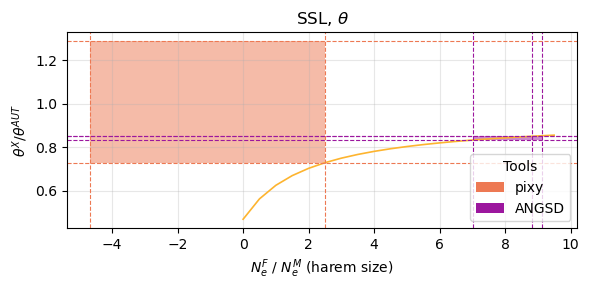

In [127]:
combine_stats(coords_pixy = np.array([(-4.67008, 1.28861), (2.49891, 0.72912)]), 
              coords_ANGSD = np.array([(8.83231, 0.85095), (9.11529, 0.85316), (7.01638, 0.83352)]), 
              alpha=3, 
              ylabel=r"$\theta^X / \theta^{AUT}$",
              title=r"SSL, $\theta$")

### Figure S11: Effective population size ratios as a function of X-linked diversity

In [422]:
def get_dependencies(thetaAUT, thetaX, ylbl=0, minthetaX=0):

    athetaX = np.sort(np.unique(np.r_[np.linspace(minthetaX, thetaAUT, 1000), thetaX]))

    alpha = 3
    muX = (2+alpha)/3
    muAUT = (1+alpha)/2

    NeAUT = thetaAUT/(4 * muAUT)
    aNeX = athetaX / (4 * muX)
    aNeXAUT = aNeX / NeAUT

    aNeM = (2*aNeX*NeAUT) / (16*aNeX-9*NeAUT)
    aNeF = (2*aNeX*NeAUT) / (9*NeAUT-8*aNeX)
    aNeFM = aNeF / aNeM

    # point estimate for the horizontal line
    NeX = thetaX / (4 * muX)
    NeM = (2*NeX*NeAUT) / (16*NeX-9*NeAUT)
    NeF = (2*NeX*NeAUT) / (9*NeAUT-8*NeX)
    NeFM = NeF / NeM

    thetaX_asymptote = (9 / 8) * thetaAUT * (muX / muAUT)

    _, ax = plt.subplots(figsize=(6, 3), dpi=900)
    ax.plot(athetaX, aNeXAUT, linestyle="-", linewidth=1.2, label=r"$N_e^X / N_e^{AUT}$",)
    ax.plot(athetaX, aNeFM, linestyle="-", linewidth=1.2, label=r"$N_e^F / N_e^M$")

    plt.xlabel(r"$\theta^X$")
    plt.ylabel(r"$N_e$ ratio")

    plt.axvline(x=thetaX, color='gray', linestyle='--', linewidth=0.8)
    plt.text(thetaX, ylbl, rf"$\theta^X$ = {thetaX:.6f}", rotation=90, style="italic")
    plt.axvline(x=thetaAUT, color='gray', linestyle='--', linewidth=0.8)
    plt.text(thetaAUT, ylbl, r"$\theta^{AUT}$"+f" = {thetaAUT:.6f}", rotation=90, style="italic")
    plt.axhline(y=NeFM, color='gray', linestyle='--', linewidth=0.8)
    plt.text(minthetaX*1.01, NeFM+0.2, rf"$N_e^F / N_e^M$ = {(NeFM):.2f}", style="italic")
    ax.axvline(thetaX_asymptote, color="red", linestyle=":", linewidth=1)
    plt.text(thetaX_asymptote, ylbl, r"$N_e^F/N_e^M \rightarrow \infty$", rotation=90, style="italic")

    plt.legend()
    plt.grid(alpha=0.3)

    plt.ylim(0, 8)
    plt.tight_layout()
    plt.show()

##### GSL

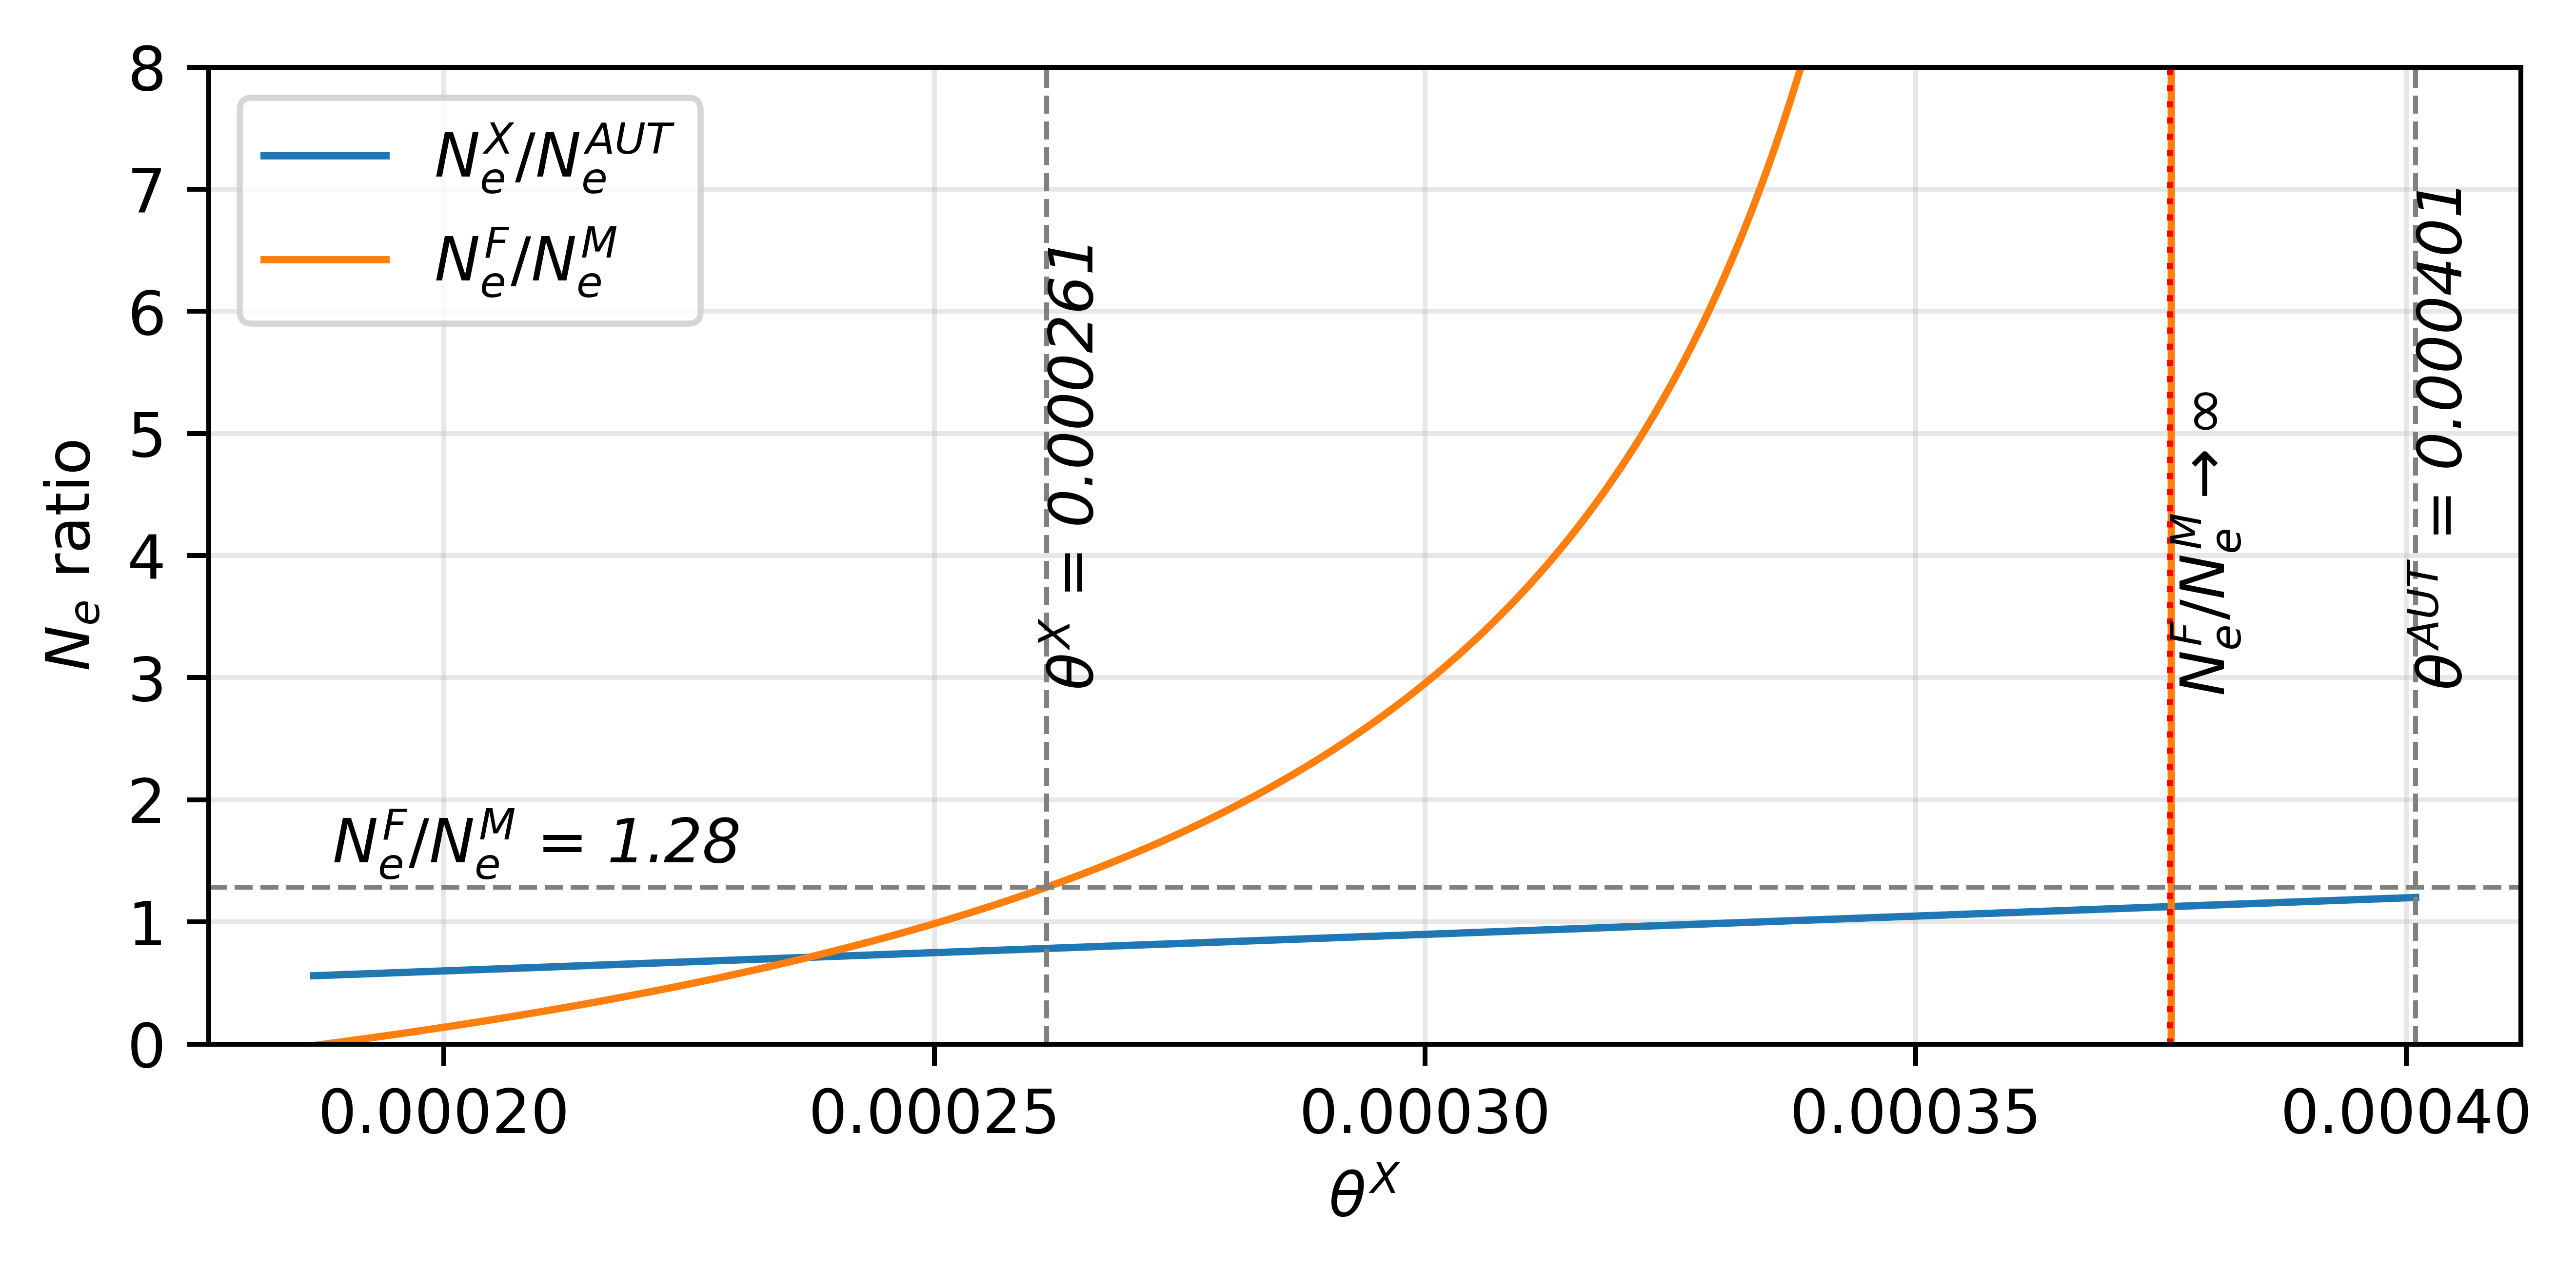

In [423]:
thetaAUT = 0.00040094
thetaX = 0.000261446
get_dependencies(thetaAUT, thetaX, ylbl=3, minthetaX=thetaX/1.4)

##### SSL

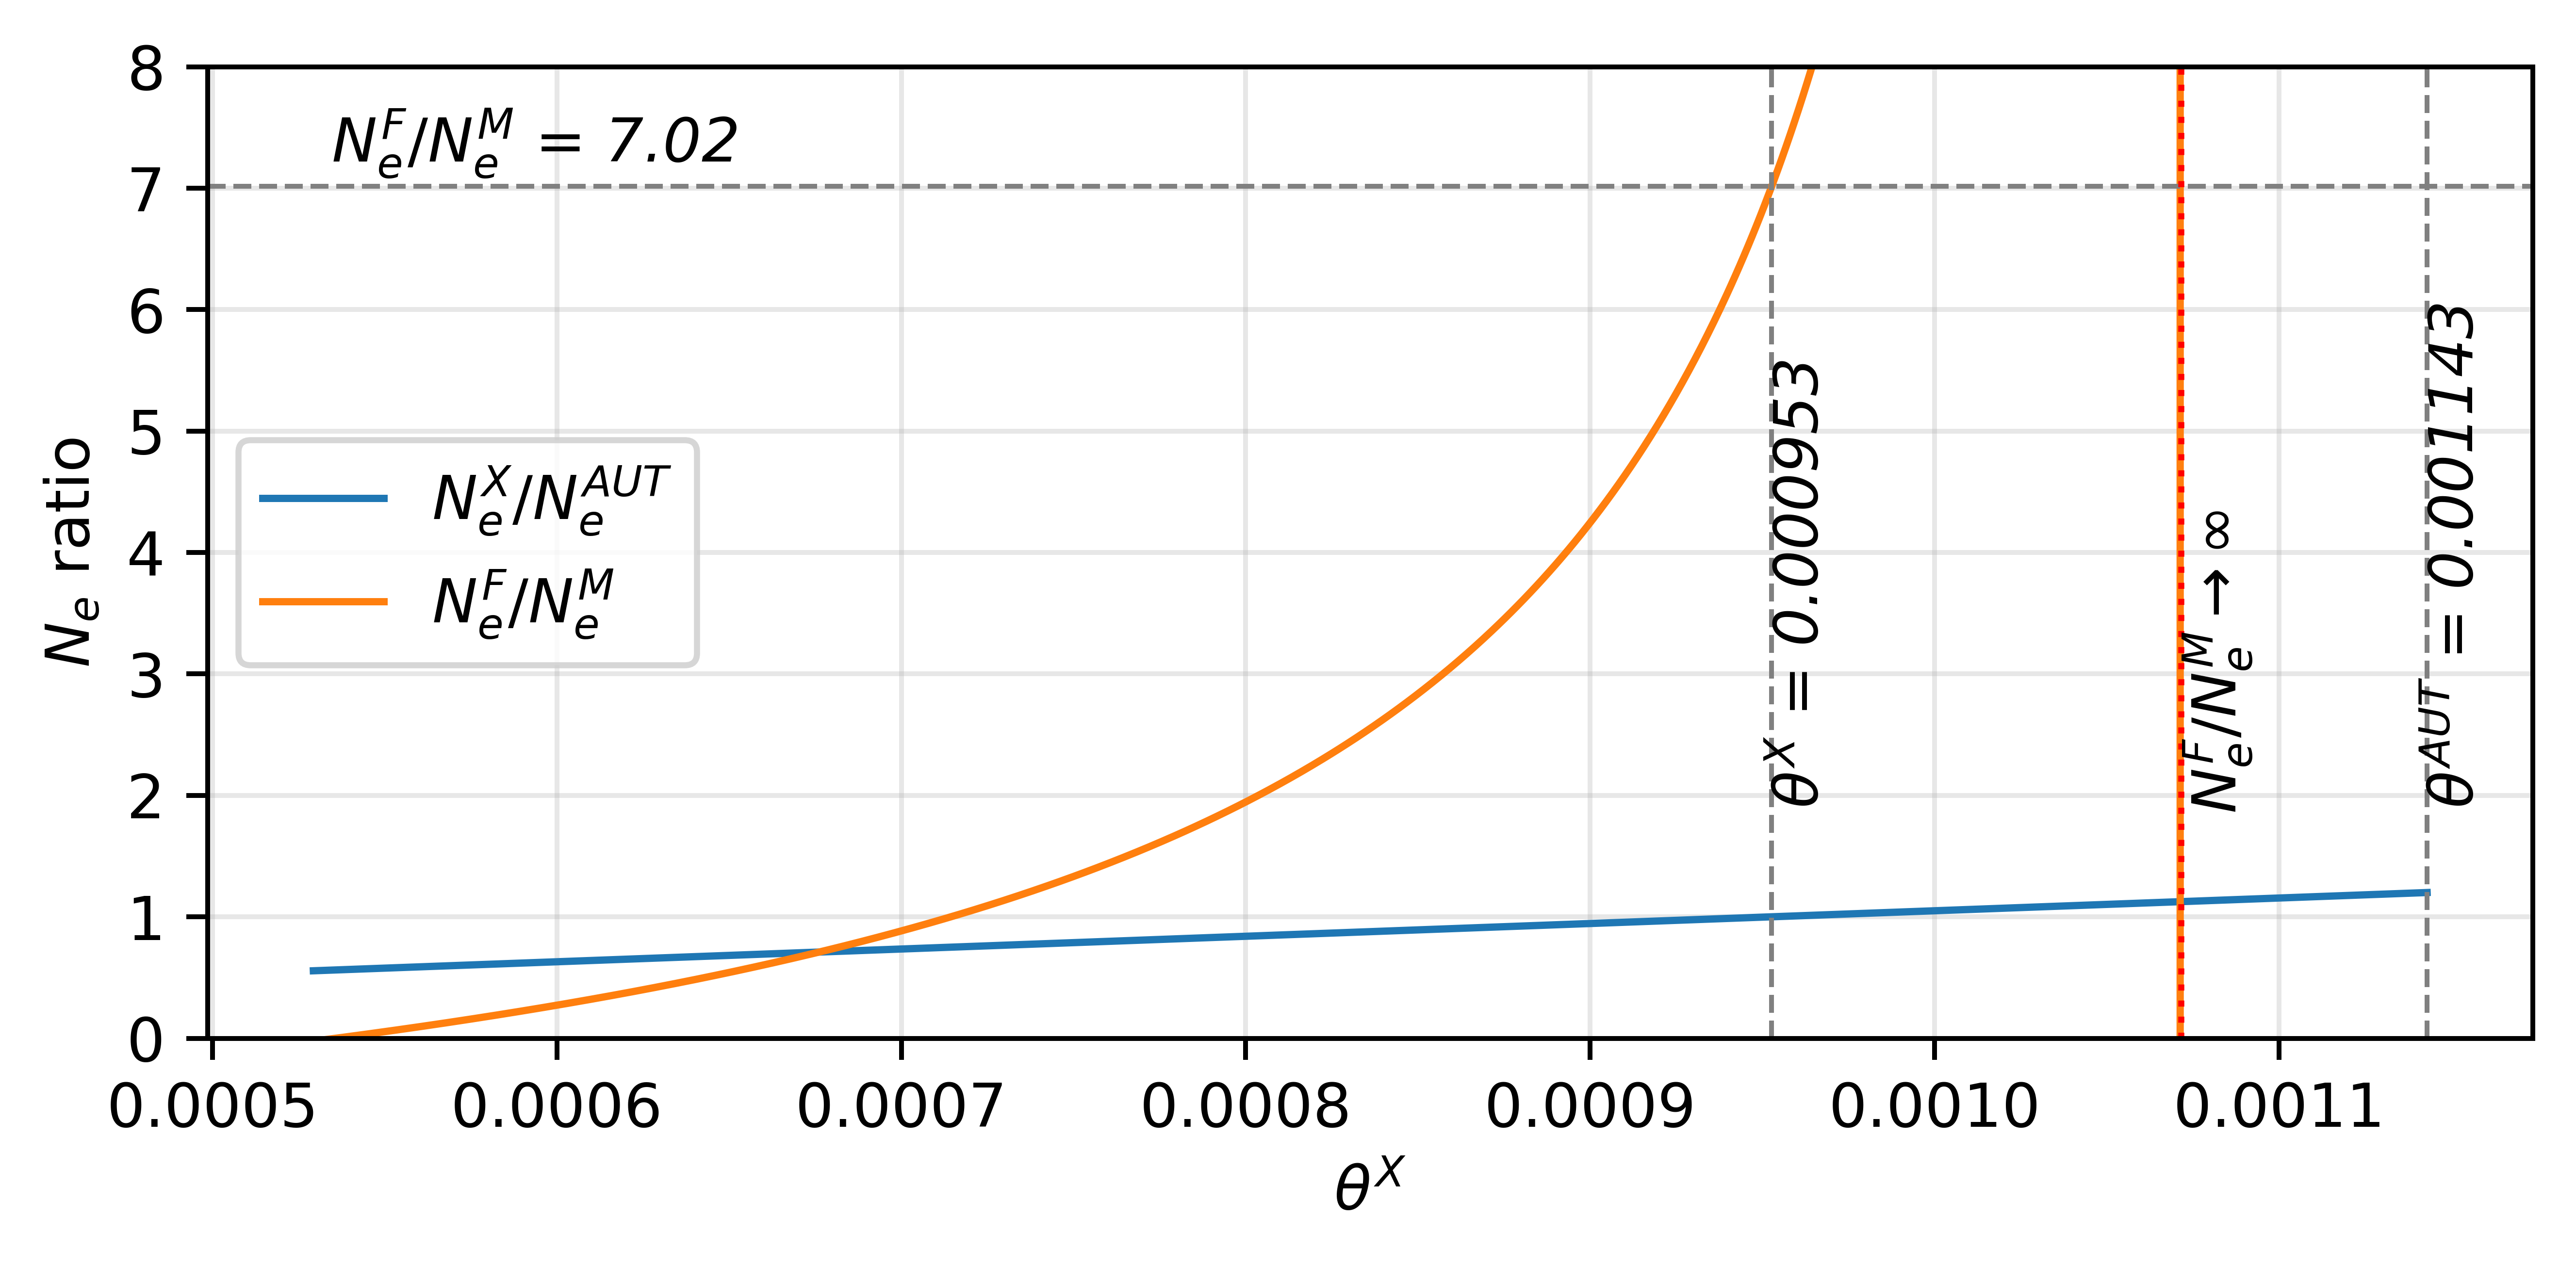

In [424]:
thetaAUT = 0.00114299
thetaX = 0.000952708
get_dependencies(thetaAUT, thetaX, ylbl=2, minthetaX=thetaX/1.8)